# **Soliton Solutions to the Korteweg–De Vries (KdV) equation**

Here we present a brief example of how the code is used to solve the KdV equation for one- and two-soliton solutions using physics-informed neural networks.

**Setup:**

In [1]:
import torch
import torch.nn as nn

import sys
from pathlib import Path

# Add parent directory to path
sys.path.append(str(Path.cwd().parent))

from models import KDV

Check GPU availability:

In [2]:
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")

CUDA available: True


## **One soliton**

Configure a model for a single soliton:

In [ ]:
INIT_PARAMS = dict(
    num_solitons             = 1,
    n_hidden_layers          = 4, 
    n_neurons_per_layer      = 32, 
    activation               = nn.Tanh,
    seed                     = current_seed, 
    verbose                  = False,
)

TRAIN_PARAMS = dict(
    adam_epochs              = 1000,
    verbose_step             = 100,
    n_collocation            = 50000, 
    n_initial                = 30000,  
    n_boundary               = 10000,
    n_momentum               = 0, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
    n_energy                 = testing_val,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
    adam_lr                  = 1e-3,   
    lbfgs_lr                 = 1.0,    
    lbfgs_history_size       = 100, 
    lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
    adaptive_sampling        = False,   
    logging                  = False, #new parameter, stops loss logging bottleneck for quick training (no loss history)
    verbose                  = False,
)

TRAIN_WEIGHTS = dict( #seperated out from the train params
    w_ic                     = 5.0,    
    w_bc                     = 2.0,    
    w_pde                    = 15.0,
    w_momentum               = 1.0,
    w_energy                 = 0.1,
)

Create an instance of the class:

In [4]:
model = KDV(INIT_PARAMS)

Using device: cuda
Testing domain created with 1000x1000 grid points.
[gpu mem] after __init__            alloc     0.0 MB  reserved     2.0 MB  peak     0.0 MB


Train the model:

In [ ]:
training_stats, domain = model.fit(TRAIN_PARAMS)

[gpu mem] after setup_training_domain alloc     0.9 MB  reserved     2.0 MB  peak     0.9 MB
Training domain setup complete: 
                    - 50000 collocation points
                    - 30000 initial points
                    - 10000 boundary points
Using 1-soliton initial condition.
Solving over the domain: t: (-15, 15), x: (-30, 30)


/home/jairdan/miniconda3/envs/soliton-pinn/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Weighted losses [start]: IC=1.445e+00, BC=5.566e-01, PDE=2.428e-01
Starting Adam optimization...
[gpu mem] train start               alloc    18.1 MB  reserved   788.0 MB  peak    18.1 MB
Adam - Epoch 0/1000, Total Loss: 2.244153e+00
Adam - Epoch 100/1000, Total Loss: 1.018373e-02
Adam - Epoch 200/1000, Total Loss: 5.134629e-03
Adam - Epoch 300/1000, Total Loss: 2.476273e-03
Adam - Epoch 400/1000, Total Loss: 1.299950e-03
Adam - Epoch 500/1000, Total Loss: 7.866869e-04
Adam - Epoch 600/1000, Total Loss: 5.328881e-04
Adam - Epoch 700/1000, Total Loss: 3.903051e-04
Adam - Epoch 800/1000, Total Loss: 3.045517e-04
Adam - Epoch 900/1000, Total Loss: 2.497810e-04
Adam - Epoch 999/1000, Total Loss: 2.127635e-04
[gpu mem] after Adam                alloc    18.9 MB  reserved   828.0 MB  peak   743.1 MB

Starting L-BFGS optimization...
L-BFGS - Iteration 100, Total Loss: 4.701797e-05
L-BFGS - Iteration 200, Total Loss: 2.278574e-05
L-BFGS - Iteration 300, Total Loss: 1.196271e-05
L-BFGS - Iterat

Let's plot how training progressed:

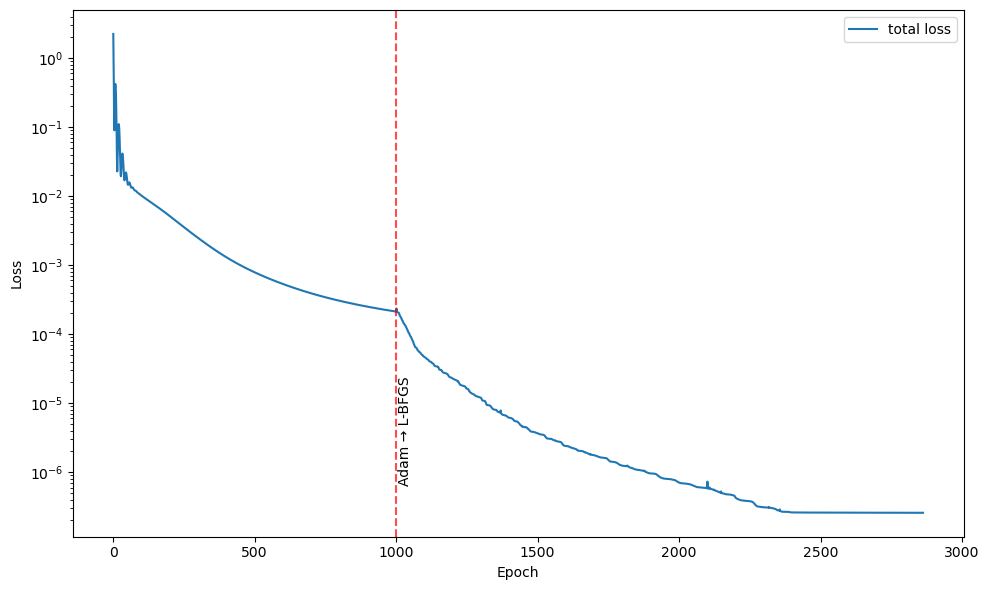

In [ ]:
fig = model.plot_losses(training_stats=training_stats, 
                        components=['total', 'pde', 'boundary',
                                    'initial', 'momentum','energy'])

Visualize the results:

[gpu mem] inside compute_solutions  alloc    18.1 MB  reserved    46.0 MB  peak   748.3 MB


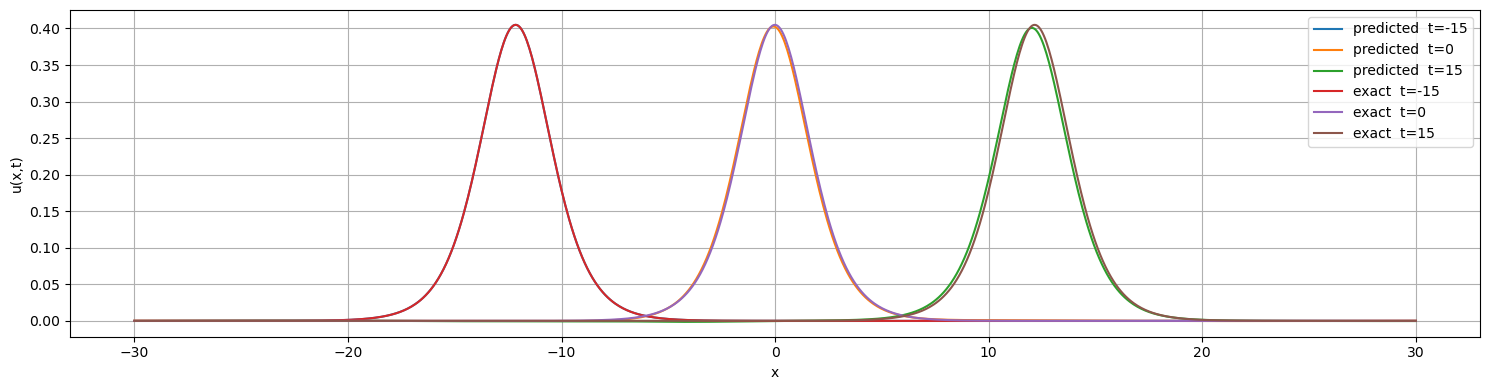

In [ ]:
fig = model.plot_profiles(t_values=[-15, 0, 15], solutions=("predicted", "exact"))

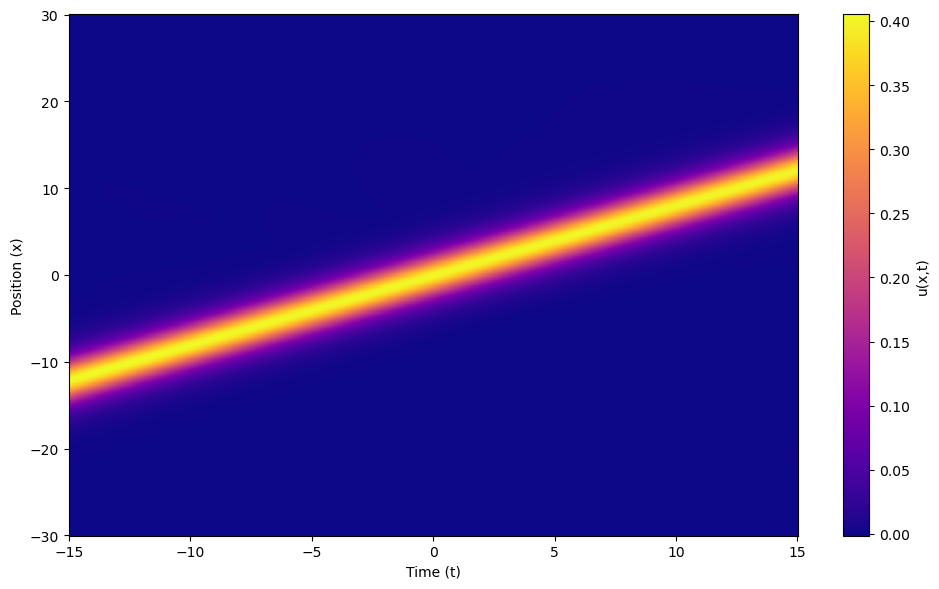

In [ ]:
fig_1 = model.plot_spacetime()
fig_2 = model.plot_spacetime(scatter_which=['initial', 'collocation', 
                                            'boundary'],
                             training_domain=domain) #call to scatter


We can also use the test method to view the point-wise error over the domain and also compute the mean and max error. Multiple error types are available, including `absolute` and `absolute-normalized`.

absolute-normalized error metrics:
Mean: 2.562180e-03
Maximum: 4.818631e-02


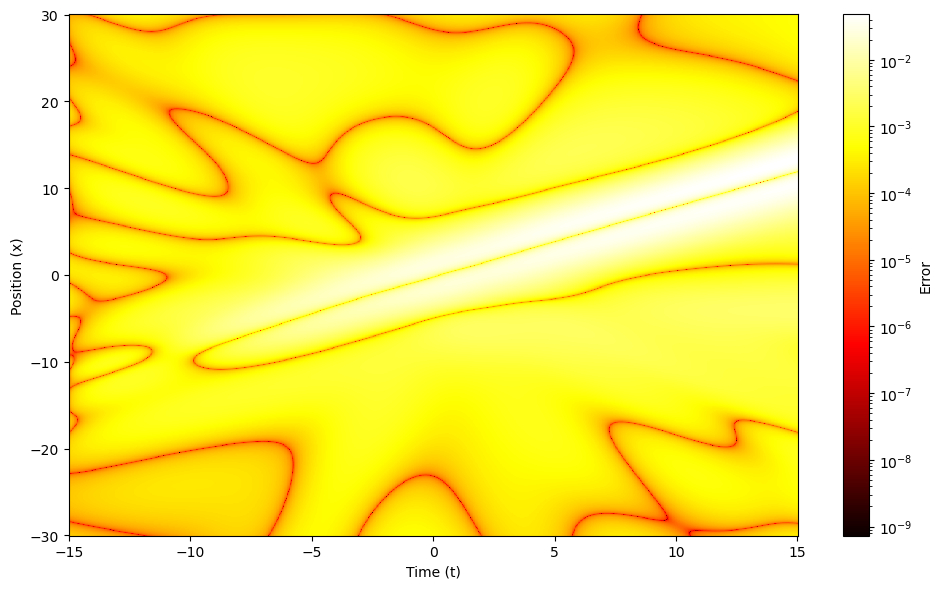

In [ ]:
model.plot_heatmap()

## **Two solitons**

Configure and train for two colliding solitons:

In [ ]:
INIT_PARAMS_2 = dict(
            num_solitons=2,
            n_hidden_layers=7, 
            n_neurons_per_layer=62, 
            activation=nn.Tanh,
            seed=current_seed, 
            verbose=False,
        )
        
TRAIN_PARAMS_2 = dict(
    adam_epochs              = 1000,
    verbose_step             = 100,
    n_collocation            = 100000, 
    n_initial                = 30000,  
    n_boundary               = 10000,
    n_momentum               = 0, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
    n_energy                 = 0,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
    adam_lr                  = 1e-3,   
    lbfgs_lr                 = 2.0,    
    lbfgs_history_size       = 100, 
    lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
    adaptive_sampling        = False,   
    logging                  = False, #new parameter, stops loss logging bottleneck for quick training (no loss history)
    verbose                  = False,
)

TRAIN_WEIGHTS_2 = dict( #seperated out from the train params
    w_ic                     = 10.0,    
    w_bc                     = 1.0,    
    w_pde                    = 100.0,
    w_momentum               = 0.005,
    w_energy                 = 0.005,
)

model_2 = KDV(INIT_PARAMS_2)
training_stats_2, domain_2 = model_2.fit(TRAIN_PARAMS_2)

Using device: cuda
Testing domain created with 1000x1000 grid points.
[gpu mem] after __init__            alloc    18.2 MB  reserved    46.0 MB  peak   748.3 MB
[gpu mem] after setup_training_domain alloc    19.2 MB  reserved    46.0 MB  peak   748.3 MB
Training domain setup complete: 
                    - 100000 collocation points
                    - 10000 initial points
                    - 10000 boundary points
Using 2-soliton initial condition.
Solving over the domain: t: (-20, 35), x: (-35, 50)
Weighted losses [start]: IC=2.246e-01, BC=1.571e-02, PDE=5.503e-02
Starting Adam optimization...
[gpu mem] train start               alloc    19.2 MB  reserved  4470.0 MB  peak    19.2 MB
Adam - Epoch 0/1000, Total Loss: 2.953535e-01
Adam - Epoch 100/1000, Total Loss: 2.786514e-02
Adam - Epoch 200/1000, Total Loss: 6.902860e-03
Adam - Epoch 300/1000, Total Loss: 3.261578e-03
Adam - Epoch 400/1000, Total Loss: 2.096157e-03
Adam - Epoch 500/1000, Total Loss: 1.973270e-03
Adam - Epoch 600/